In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file = "Foodpanda Analysis Dataset (1).csv" 
df = pd.read_csv(file)

print(df.shape)
df.head()

(6000, 20)


,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
0,C5663,Male,Adult,Peshawar,1/14/2024,O9663,8/23/2023,McDonald's,Burger,Italian,5,1478.27,Cash,38,7/19/2025,238,Active,3,10/14/2024,Cancelled
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,3,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,2,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,4,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed
4,C4339,Other,Senior,Lahore,12/29/2023,O8339,8/24/2023,KFC,Sandwich,Dessert,1,1156.69,Cash,35,12/21/2024,418,Inactive,3,3/6/2025,Cancelled


In [3]:
# Revenue calculated from delivered and delayed orders
df = df[df['delivery_status'].isin(['Delivered', 'Delayed'])]

In [4]:
df["total_revenue"]=df["price"]*df["quantity"]
df.head()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,...,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status,total_revenue
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,...,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed,2868.12
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,...,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed,1765.02
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,...,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed,925.20
5,C6543,Other,Adult,Karachi,9/28/2023,O10543,8/24/2023,Burger King,Pizza,Fast Food,...,1213.62,Cash,45,10/10/2024,418,Inactive,4,6/1/2025,Delivered,6068.10
7,C4621,Male,Adult,Peshawar,2/5/2024,O8621,8/24/2023,Pizza Hut,Pizza,Chinese,...,271.74,Cash,14,5/1/2025,429,Active,2,9/30/2024,Delivered,543.48


In [5]:
#Overall Revenue Analysis
total_revenue = df['total_revenue'].sum()
avg_order_value = df['total_revenue'].mean()
total_orders = df['total_revenue'].count()

print("Total Revenue:", total_revenue)
print("Average Order Value:", avg_order_value)
print("Total Orders:", total_orders)

Total Revenue: 9691770.83
Average Order Value: 2403.713003472222
Total Orders: 4032


In [6]:
# Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract year
df['year'] = df['order_date'].dt.year

# Group by year and calculate total revenue
yearly_revenue = df.groupby('year')['total_revenue'].sum().reset_index()

print(yearly_revenue)


   year  total_revenue
0  2023     1862388.62
1  2024     4750959.00
2  2025     3078423.21


In [7]:
# Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract year and month
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['quarter'] = df['order_date'].dt.to_period('Q')

# For each quarter, list the months present
quarter_months = df.groupby(['year','quarter'])['month'].unique().reset_index()

print(quarter_months.sort_values(['year','quarter']))

   year quarter         month
0  2023  2023Q3        [8, 9]
1  2023  2023Q4  [10, 11, 12]
2  2024  2024Q1     [1, 2, 3]
3  2024  2024Q2     [4, 5, 6]
4  2024  2024Q3     [7, 8, 9]
5  2024  2024Q4  [10, 11, 12]
6  2025  2025Q1     [1, 2, 3]
7  2025  2025Q2     [4, 5, 6]
8  2025  2025Q3        [7, 8]


In [8]:
#How do payment method preferences influence revenue generation
payment_analysis = df.groupby('payment_method')['total_revenue'].agg(['sum','mean','count'])
print(payment_analysis)

                       sum         mean  count
payment_method                                
Card            3160535.44  2341.137363   1350
Cash            3335086.08  2430.820758   1372
Wallet          3196149.31  2439.808634   1310


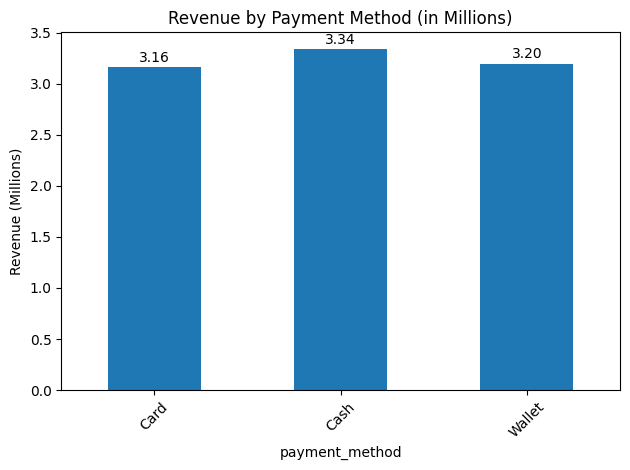

In [9]:
# Convert to millions
values = payment_analysis['sum'] / 1000000

# Plot
ax = values.plot(kind='bar')

plt.title("Revenue by Payment Method (in Millions)")
plt.ylabel("Revenue (Millions)")
plt.xticks(rotation=45)

# Add values on top of bars
for i, v in enumerate(values):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()

In [10]:
# Overall analysis of payment methods completed; now moving to year-by-year comparison to check differences

# Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract year
df['year'] = df['order_date'].dt.year

# Group by year and payment method
payment_analysis_yearly = df.groupby(['year','payment_method'])['total_revenue'].agg(['sum','mean','count'])

print(payment_analysis_yearly)
 

                            sum         mean  count
year payment_method                                
2023 Card             607982.24  2522.747884    241
     Cash             632090.60  2469.103906    256
     Wallet           622315.78  2540.064408    245
2024 Card            1585468.64  2284.536945    694
     Cash            1635243.24  2404.769471    680
     Wallet          1530247.12  2448.395392    625
2025 Card             967084.56  2330.324241    415
     Cash            1067752.24  2448.973028    436
     Wallet          1043586.41  2371.787295    440


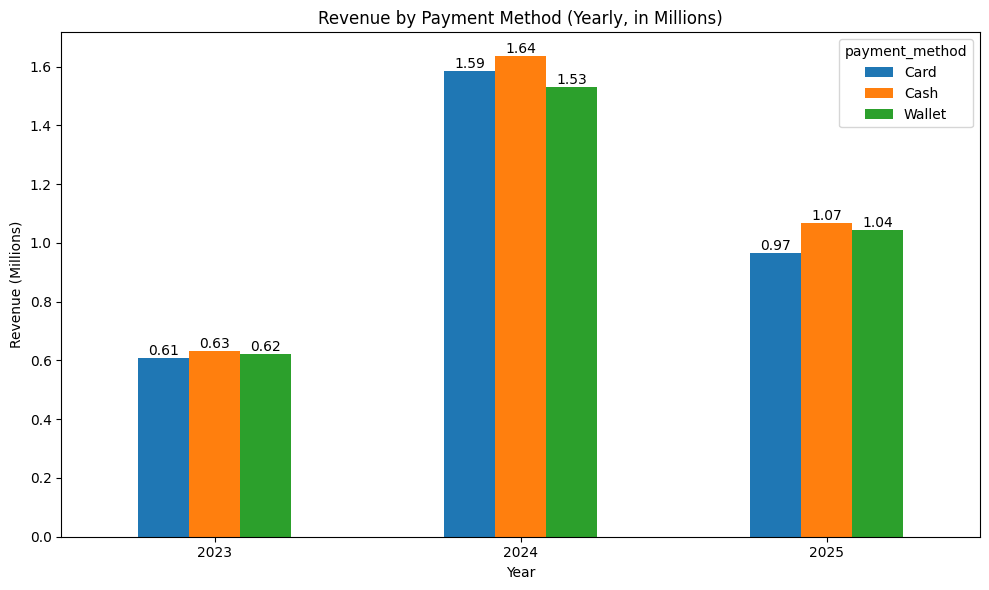

In [11]:
# Reset index so 'year' and 'payment_method' become columns
payment_analysis_yearly = payment_analysis_yearly.reset_index()

# Pivot the table to have payment methods as columns
pivot_data = payment_analysis_yearly.pivot(index='year', columns='payment_method', values='sum') / 1_000_000

# Plot
ax = pivot_data.plot(kind='bar', figsize=(10,6))

plt.title("Revenue by Payment Method (Yearly, in Millions)")
plt.ylabel("Revenue (Millions)")
plt.xlabel("Year")
plt.xticks(rotation=0)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge")

plt.tight_layout()

In [12]:

# Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract quarter and year
df['quarter'] = df['order_date'].dt.to_period('Q')

# Group by quarter and payment method
payment_analysis_quarterly = df.groupby(['quarter','payment_method'])['total_revenue'].agg(['sum','mean','count']).reset_index()

print(payment_analysis_quarterly)




   quarter payment_method        sum         mean  count
0   2023Q3           Card  206316.01  2679.428701     77
1   2023Q3           Cash  162913.28  2327.332571     70
2   2023Q3         Wallet  196993.16  2525.553333     78
3   2023Q4           Card  401666.23  2449.184329    164
4   2023Q4           Cash  469177.32  2522.458710    186
5   2023Q4         Wallet  425322.62  2546.842036    167
6   2024Q1           Card  376179.00  2225.911243    169
7   2024Q1           Cash  366436.40  2276.002484    161
8   2024Q1         Wallet  390012.53  2549.101503    153
9   2024Q2           Card  412327.16  2369.696322    174
10  2024Q2           Cash  413453.53  2461.032917    168
11  2024Q2         Wallet  409391.19  2574.787358    159
12  2024Q3           Card  394809.11  2145.701685    184
13  2024Q3           Cash  413220.11  2308.492235    179
14  2024Q3         Wallet  423352.84  2300.830652    184
15  2024Q4           Card  402153.37  2408.104012    167
16  2024Q4           Cash  4421

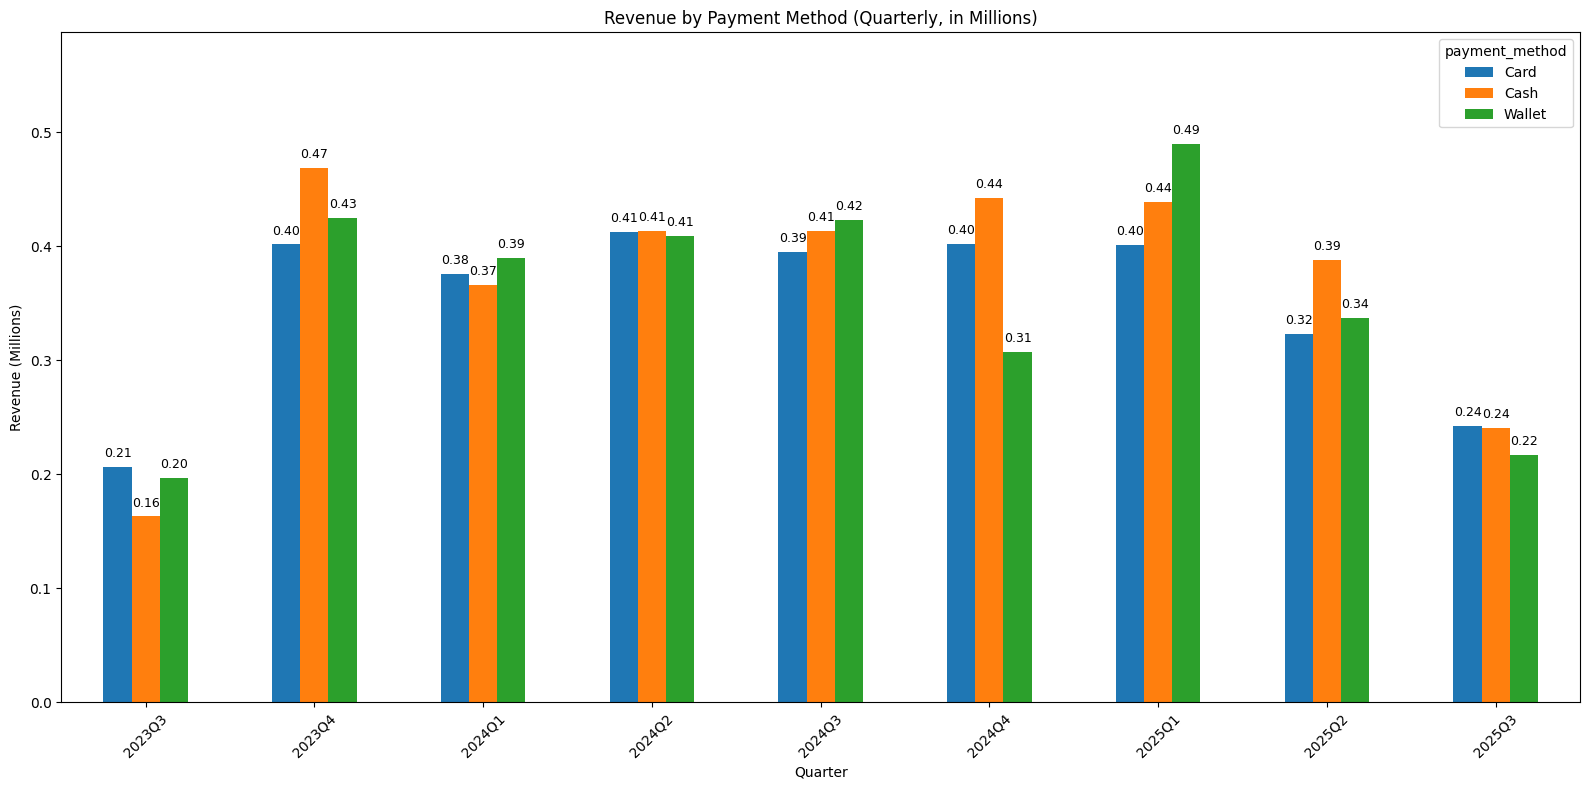

In [13]:

# Pivot for plotting (sum of revenue, converted to millions)
pivot_data = payment_analysis_quarterly.pivot(index='quarter', columns='payment_method', values='sum') / 1_000_000

# Plot grouped bar chart
ax = pivot_data.plot(kind='bar', figsize=(16,8))  # wider and taller figure

plt.title("Revenue by Payment Method (Quarterly, in Millions)")
plt.ylabel("Revenue (Millions)")
plt.xlabel("Quarter")
plt.xticks(rotation=45)

# Add values on top of bars with spacing
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=5, fontsize=9)

# Expand y-axis so labels don’t get cut off
ax.set_ylim(0, pivot_data.max().max() * 1.2)

plt.tight_layout()
plt.show()


In [14]:
# Analysis(Payment Method) 
#Dominant Payment Method: Cash consistently remains the highest revenue generator in all three years, 
#though the margin between Card, Cash, and Wallet is relatively slim.

#1. The "Post-Hype" 2025 Correction
#The jump in 2024 (nearly triple 2023 levels) suggests a period of aggressive expansion—likely through heavy discounting,
#marketing blitzes, or expansion into new cities.Why the 2025 drop? The decline in 2025 (specifically visible in the quarterly graph)
#often happens when an app moves from customer acquisition (burning cash for growth) to retention/profitability.
#You are likely seeing the result of higher delivery fees or fewer "50% off" vouchers, which naturally thins out the casual user base.

#2023 Q4 vs. 2024 Q4: There is a huge year-over-year jump in the final quarter. 
#In food delivery, Q4 is usually peak season due to colder weather (people stay in) and holiday gatherings.

#: The massive jump in Wallet revenue in early 2025 suggests a promotional event. Delivery apps often run 
#"Top up your wallet and get 20% extra" campaigns to lock users into the ecosystem. 
#The fact that it dropped immediately after suggests those users spent their balance and didn't necessarily "refill" at the same rate.

In [15]:
#The end 
#How do payment method preferences influence revenue generation

In [16]:
#How do food category choices influence revenue generation

category_analysis = df.groupby('category')['total_revenue'].agg(['sum','mean','count'])
print(category_analysis)

                    sum         mean  count
category                                   
Chinese      1939062.36  2432.951518    797
Continental  1990548.60  2433.433496    818
Dessert      1844426.61  2382.980116    774
Fast Food    1905894.74  2370.515846    804
Italian      2011838.52  2397.900501    839


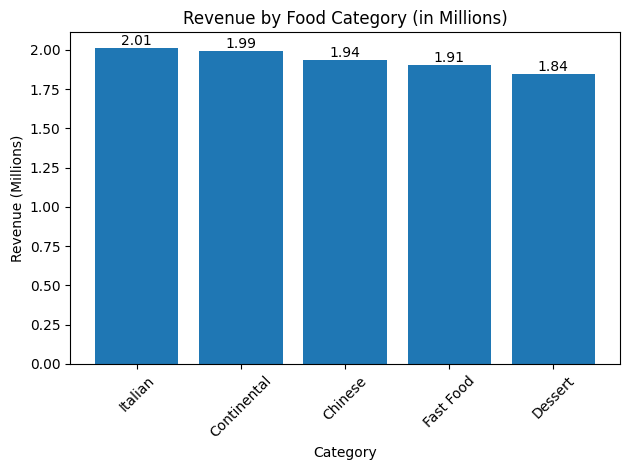

In [17]:
# Sort values (very important for clarity)
data = category_analysis['sum'].sort_values(ascending=False) / 1000000

plt.figure()

bars = plt.bar(data.index, data.values)

plt.title("Revenue by Food Category (in Millions)")
plt.xlabel("Category")
plt.ylabel("Revenue (Millions)")
plt.xticks(rotation=45)

# 🔥 Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [18]:
# Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# --- YEARLY ANALYSIS ---
df['year'] = df['order_date'].dt.year
category_yearly = df.groupby(['year','category'])['total_revenue'].agg(['sum','mean','count']).reset_index()

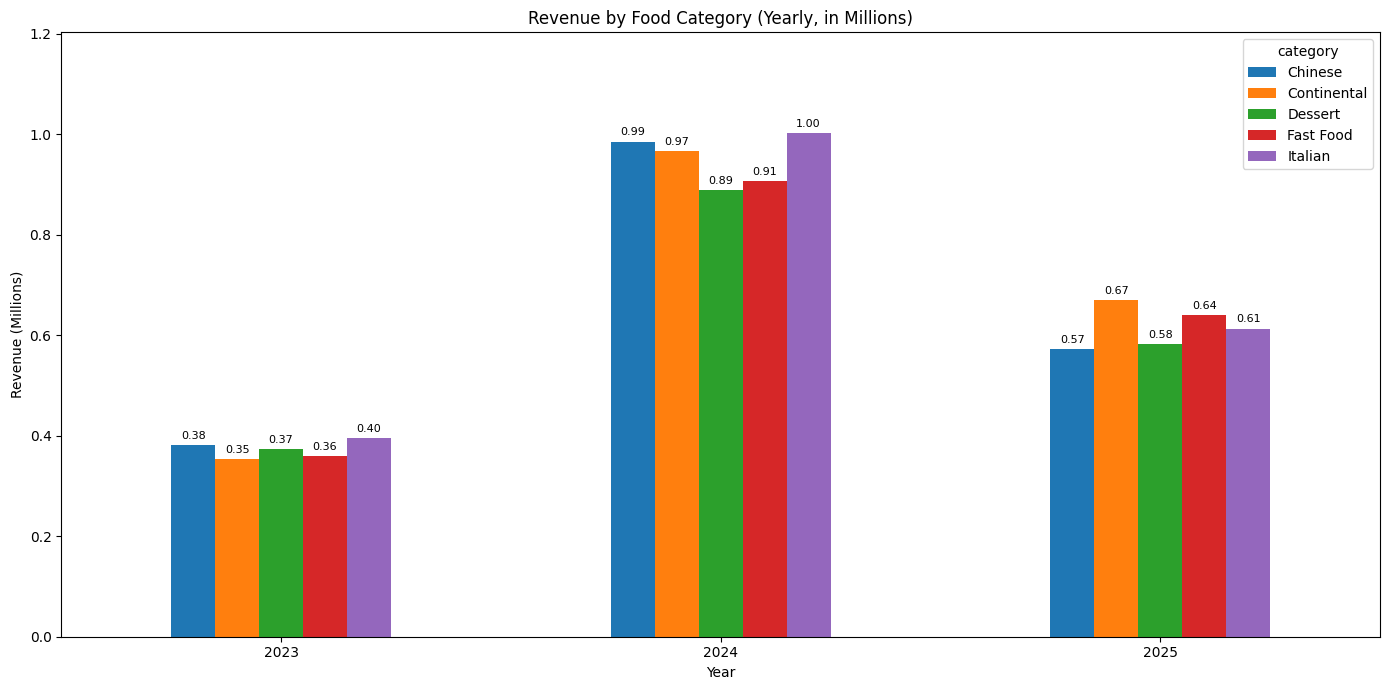

In [19]:
df['year'] = df['order_date'].dt.year
category_yearly = df.groupby(['year','category'])['total_revenue'].agg(['sum','mean','count']).reset_index()

# Pivot for plotting (sum in millions)
pivot_yearly = category_yearly.pivot(index='year', columns='category', values='sum') / 1_000_000

# Plot yearly grouped bar chart
ax = pivot_yearly.plot(kind='bar', figsize=(14,7))
plt.title("Revenue by Food Category (Yearly, in Millions)")
plt.ylabel("Revenue (Millions)")
plt.xlabel("Year")
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=3)
ax.set_ylim(0, pivot_yearly.max().max() * 1.2)
plt.tight_layout()
plt.savefig("Yearly_revenue_bycate.png", dpi=300, bbox_inches='tight')  
plt.show()

In [20]:
# --- QUARTERLY ANALYSIS ---
df['quarter'] = df['order_date'].dt.to_period('Q')
category_quarterly = df.groupby(['quarter','category'])['total_revenue'].agg(['sum','mean','count']).reset_index()

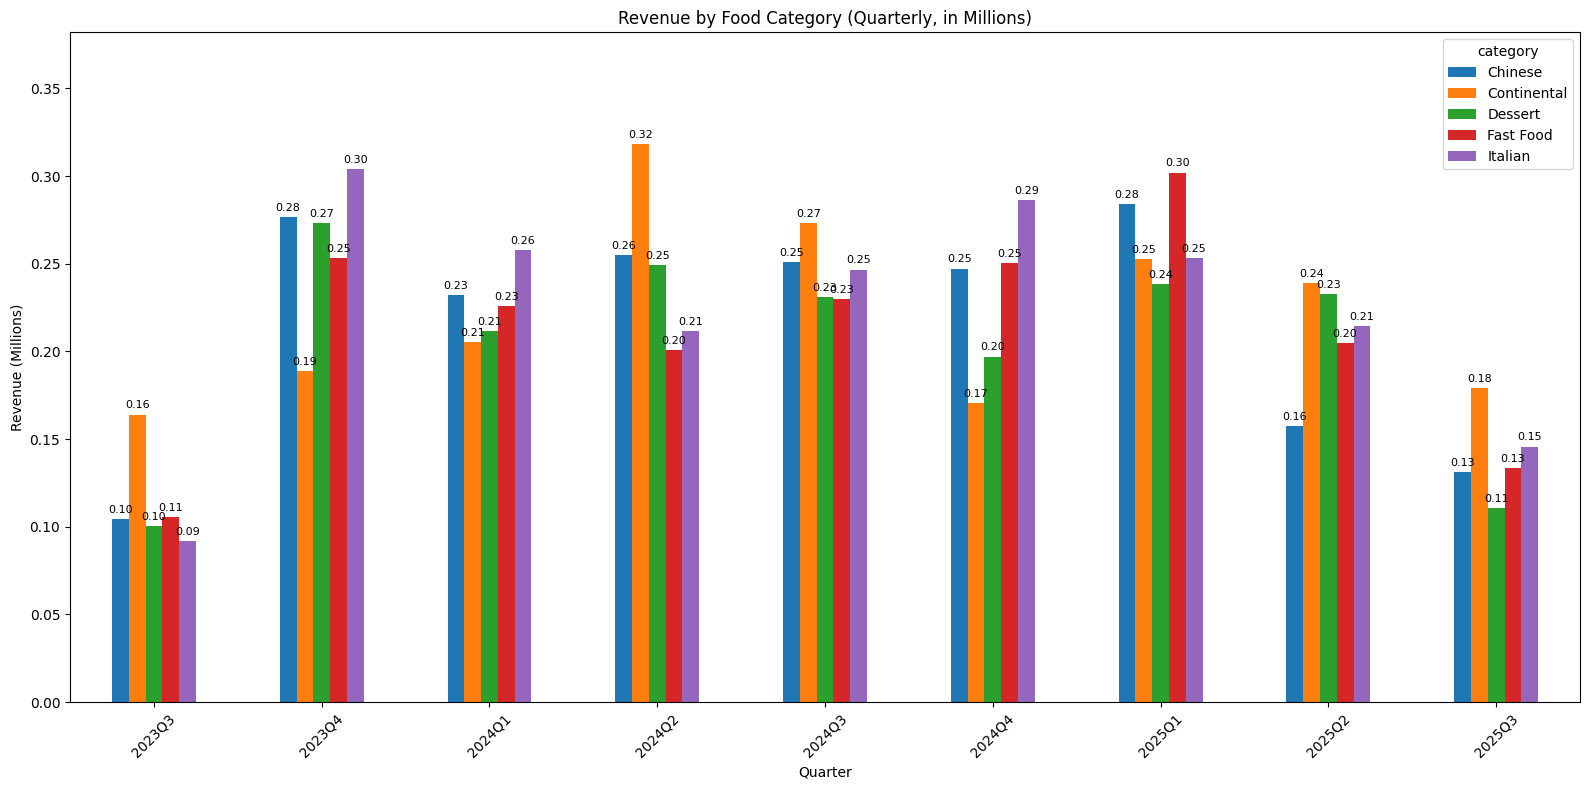

In [21]:
# Pivot for plotting (sum in millions)
pivot_quarterly = category_quarterly.pivot(index='quarter', columns='category', values='sum') / 1_000_000

# Plot quarterly grouped bar chart
ax = pivot_quarterly.plot(kind='bar', figsize=(16,8))
plt.title("Revenue by Food Category (Quarterly, in Millions)")
plt.ylabel("Revenue (Millions)")
plt.xlabel("Quarter")
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=3)
ax.set_ylim(0, pivot_quarterly.max().max() * 1.2)
plt.tight_layout()
plt.savefig("quarterly_revenue_bycate.png", dpi=300, bbox_inches='tight')  # high resolution PNG
plt.show()

In [22]:
#anylasis 
#The Underperformer: Dessert consistently brings in the least revenue (1.84M total). 
#This is typical for food delivery, as desserts are often "add-ons" rather than primary meal orders.

#Market Saturation: All categories are remarkably close in total revenue. 
#This suggests your app has a well-balanced vendor list; you aren't overly reliant on just one type of food.

#. Yearly Shifts (The 2024 Peak)
#2024 Dominance: Similar to your payment graphs, 2024 saw a massive explosion. Italian hit a peak of 1.00M that year.
#2025 Preference Shift: Interestingly, while Italian ruled 2024, Continental food became the top earner in 
#2025 (0.67M), surpassing Italian (0.61M). This might indicate a shift in user tastes toward diverse "main course" options or 
#the addition of popular new Continental vendors.
#Resilience of Fast Food: Fast food saw one of the smallest percentage drops between 2024 and 2025 compared to others, suggesting it is a "recession-proof" category that users stick with even when tightening their belts.

In [23]:
#strategic Analysis & "The Why"
#Bundle Desserts: Since Desserts are lagging, don't market them alone. Use the data to create "Italian + Dessert" or 
#"Fast Food + Dessert" bundles to increase the Average Order Value (AOV).

#Capitalize on Continental: Continental food is your rising star in 2025. 
#You should consider giving these vendors more visibility on the app's home screen, as they seem to be the current customer favorite.

#The "Discount Fatigue" Signal: The sharp drop in 2025Q3 across all categories suggests that the 2024 growth was 
#likely "bought" with heavy subsidies. Now that prices have normalized (or increased), users are ordering less frequently across the board.

In [24]:
#end 
#How do food category choices influence revenue generation

In [25]:
#How do customer demographics influence revenue generation
#by age 

#Customer Demographics Analysis
age_analysis = df.groupby('age')['total_revenue'].agg(['sum','mean'])
print(age_analysis)

                 sum         mean
age                              
Adult     3178431.54  2393.397244
Senior    3129468.71  2392.560176
Teenager  3383870.58  2423.976060


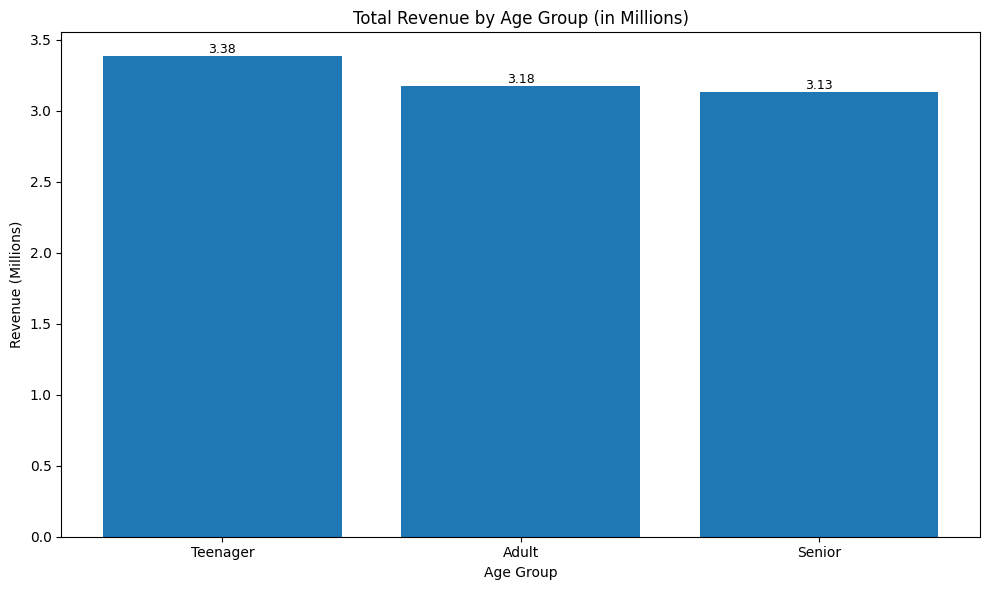

In [26]:
# Convert revenue to millions
data = (age_analysis['sum'] / 1_000_000).sort_values(ascending=False)

plt.figure(figsize=(10,6))

bars = plt.bar(data.index, data.values)

plt.title("Total Revenue by Age Group (in Millions)")
plt.xlabel("Age Group")
plt.ylabel("Revenue (Millions)")
plt.xticks(rotation=0)

# 🔥 Add value labels (formatted to 2 decimals for clarity)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("AGE_TOTAL.png", dpi=300, bbox_inches='tight')
plt.show()

In [27]:
# Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# --- YEARLY ANALYSIS ---
df['year'] = df['order_date'].dt.year
age_yearly = df.groupby(['year','age'])['total_revenue'].sum().reset_index()

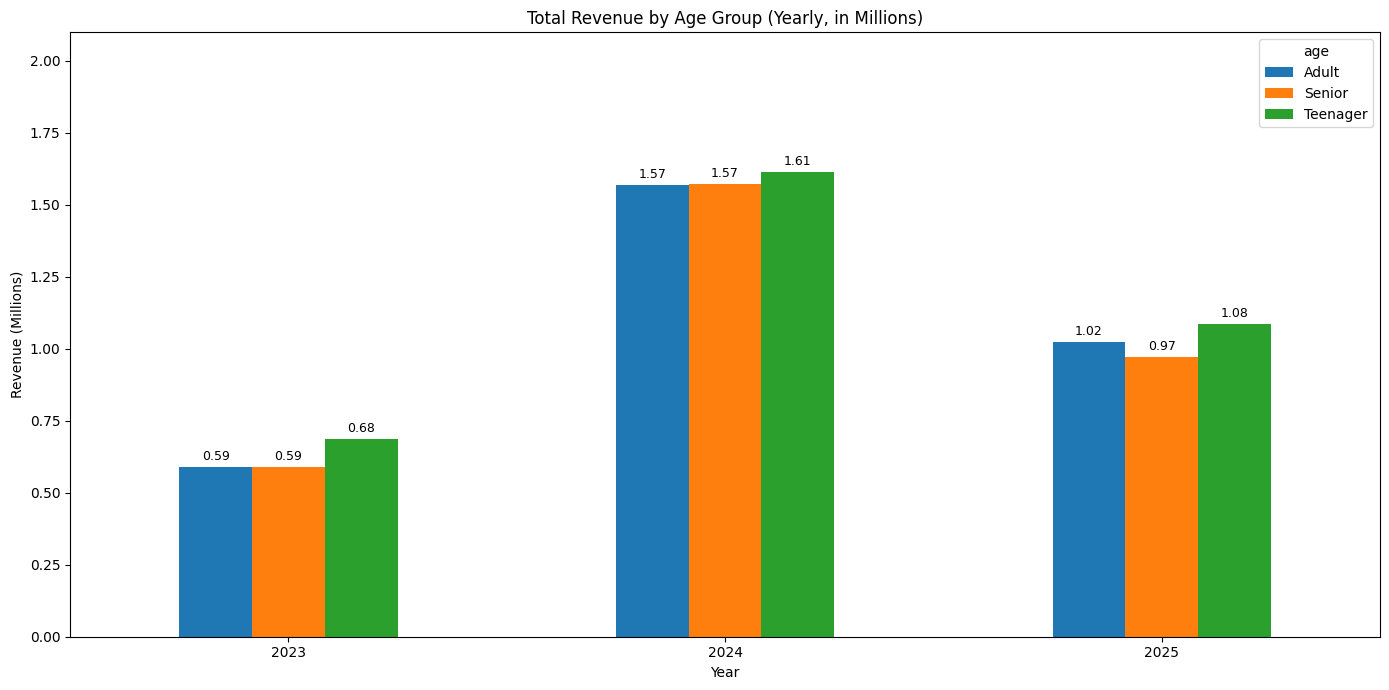

In [28]:

# --- YEARLY ANALYSIS ---
df['order_date'] = pd.to_datetime(df['order_date'])
df['year'] = df['order_date'].dt.year

age_yearly = df.groupby(['year','age'])['total_revenue'].sum().reset_index()
age_yearly['total_revenue'] = age_yearly['total_revenue'] / 1_000_000  # convert to millions

pivot_yearly = age_yearly.pivot(index='year', columns='age', values='total_revenue')

ax = pivot_yearly.plot(kind='bar', figsize=(14,7))
plt.title("Total Revenue by Age Group (Yearly, in Millions)")
plt.ylabel("Revenue (Millions)")
plt.xlabel("Year")
plt.xticks(rotation=0)

#  Force labels above bars (always visible)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3, fontsize=9)

# Add margin so labels don’t get cut off
ax.set_ylim(0, pivot_yearly.max().max() * 1.3)

plt.tight_layout()
plt.savefig("Age_Yearly.png", dpi=300, bbox_inches='tight')
plt.show()

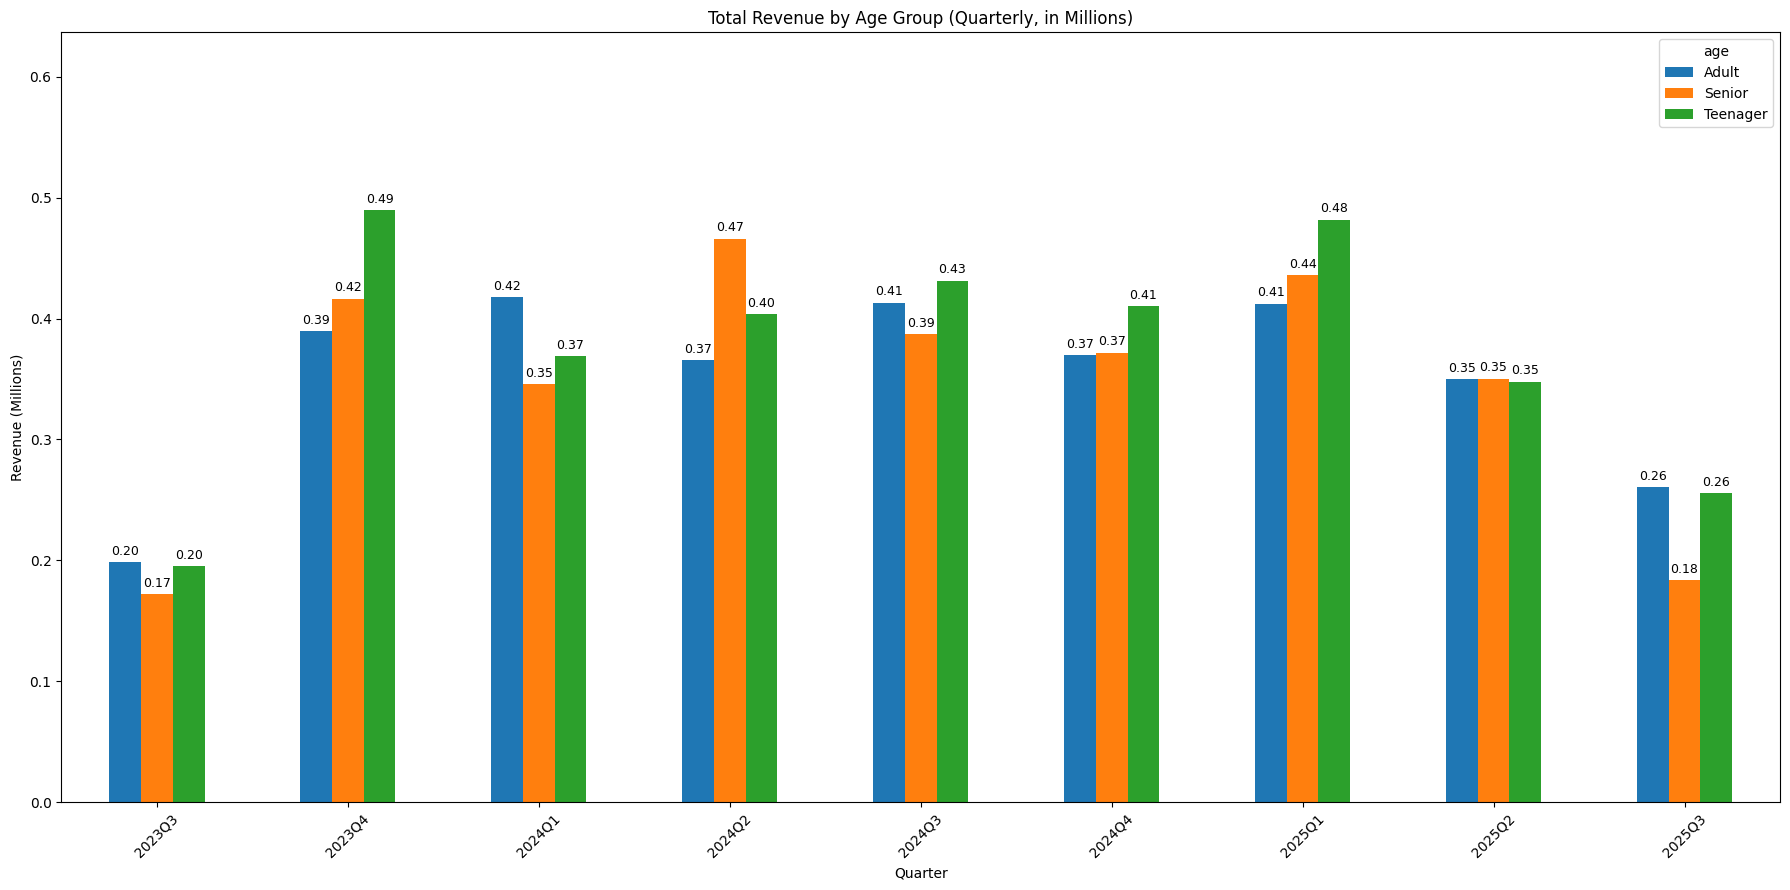

In [29]:
# --- QUARTERLY ANALYSIS ---
df['quarter'] = df['order_date'].dt.to_period('Q')

age_quarterly = df.groupby(['quarter','age'])['total_revenue'].sum().reset_index()
age_quarterly['total_revenue'] = age_quarterly['total_revenue'] / 1_000_000  # convert to millions

pivot_quarterly = age_quarterly.pivot(index='quarter', columns='age', values='total_revenue')

ax = pivot_quarterly.plot(kind='bar', figsize=(18,9))
plt.title("Total Revenue by Age Group (Quarterly, in Millions)")
plt.ylabel("Revenue (Millions)")
plt.xlabel("Quarter")
plt.xticks(rotation=45)

# Labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3, fontsize=9)

ax.set_ylim(0, pivot_quarterly.max().max() * 1.3)
plt.savefig("Age_quarterly.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [30]:
#Teenagers are your single largest revenue source, totaling 3.38M. This is often seen in 
#food delivery because students and young adults prioritize convenience and "fast food"
#culture more than other groups.

#Teenagers show the most dramatic "peaks." In 2023Q4 and 2025Q1,
#their revenue hit 0.49M and 0.48M, respectively. This group is likely highly responsive
#to social media marketing and app-specific promotions 
#(like the "Wallet" spike we saw earlier).

#The School/University Factor: Notice the dips in 2024Q1 and 2025Q2 for teenagers. 
#These often correlate with exam seasons or holidays when students might travel home 
#and stop ordering to their usual addresses.

#. Senior & Adult Stability
#The "Silent" Heavy Lifters: While Seniors bring in the least total revenue (3.13M), 
#they are surprisingly consistent. In 2024, they actually tied with Adults at 1.57M.

#Reliable Growth: The Adult group (expected to be the 25–50 age range) shows the most 
#"controlled" trajectory. They don't have the wild spikes that teenagers do, 
#making them a more predictable demographic for long-term financial planning.

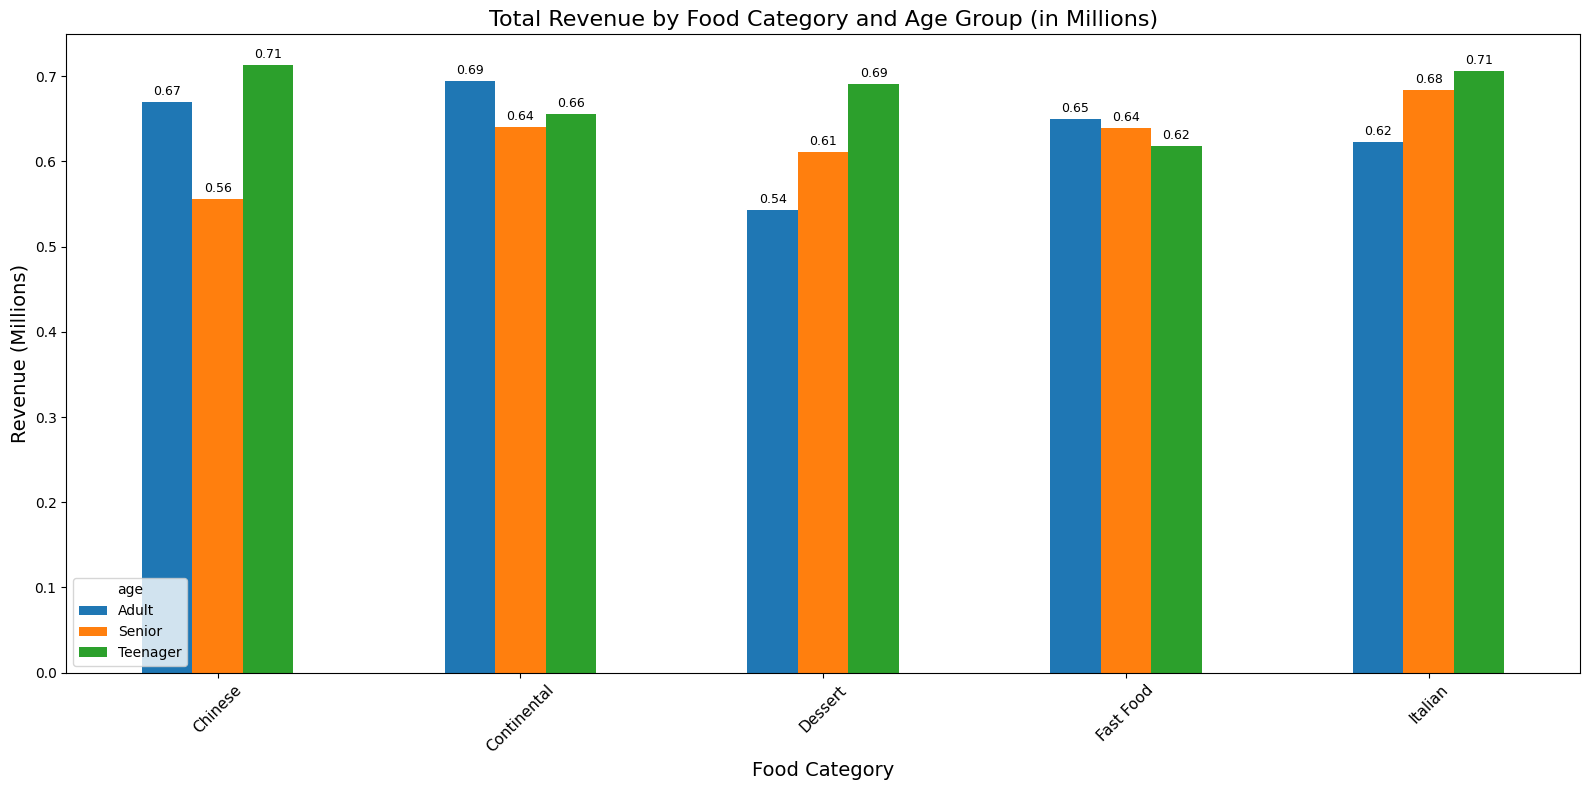

In [31]:
#end
#How do customer demographics influence revenue generation
#by age 


# Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# --- GROUP BY FOOD CATEGORY + AGE GROUP ---
category_age = df.groupby(['category','age'])['total_revenue'].sum().reset_index()

# Convert to millions for readability
category_age['total_revenue'] = category_age['total_revenue'] / 1_000_000

# Pivot for plotting
pivot_cat_age = category_age.pivot(index='category', columns='age', values='total_revenue')

# Plot grouped bar chart
ax = pivot_cat_age.plot(kind='bar', figsize=(16,8))
plt.title("Total Revenue by Food Category and Age Group (in Millions)", fontsize=16)
plt.ylabel("Revenue (Millions)", fontsize=14)
plt.xlabel("Food Category", fontsize=14)
plt.xticks(rotation=45, fontsize=11)

# Add labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


In [32]:
#How do customer demographics influence revenue generation
#by City
city_analysis = df.groupby('city')['total_revenue'].agg(['sum','mean'])
print(city_analysis)

                  sum         mean
city                              
Islamabad  1917982.07  2403.486303
Karachi    1815477.23  2303.905114
Lahore     2001426.36  2486.243925
Multan     2054388.34  2445.700405
Peshawar   1902496.83  2375.152097


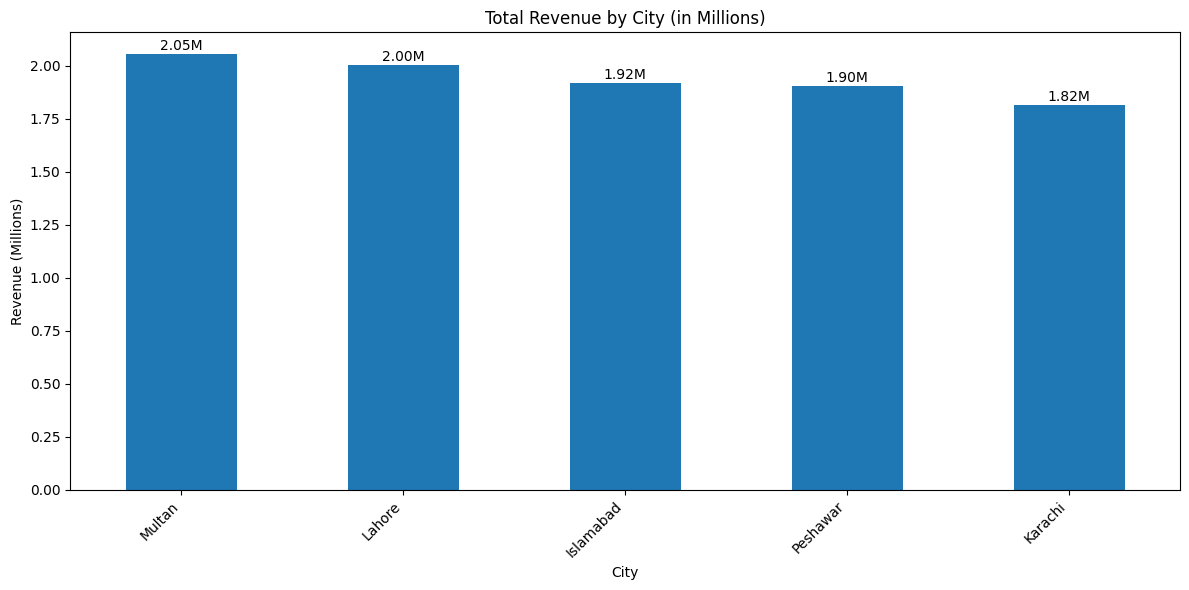

In [33]:
# Total Revenue by City (in Millions) - Sorted
city_revenue_m = (city_analysis['sum'] / 1_000_000).sort_values(ascending=False)

# Create larger bar chart
ax = city_revenue_m.plot(kind='bar', figsize=(12, 6))

# Add value labels above each bar
for i, value in enumerate(city_revenue_m):
    ax.text(i, value + 0.02, f'{value:.2f}M', ha='center')

plt.title("Total Revenue by City (in Millions)")
plt.ylabel("Revenue (Millions)")
plt.xlabel("City")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("CITY_TOTAL.png", dpi=300, bbox_inches='tight')
plt.show()

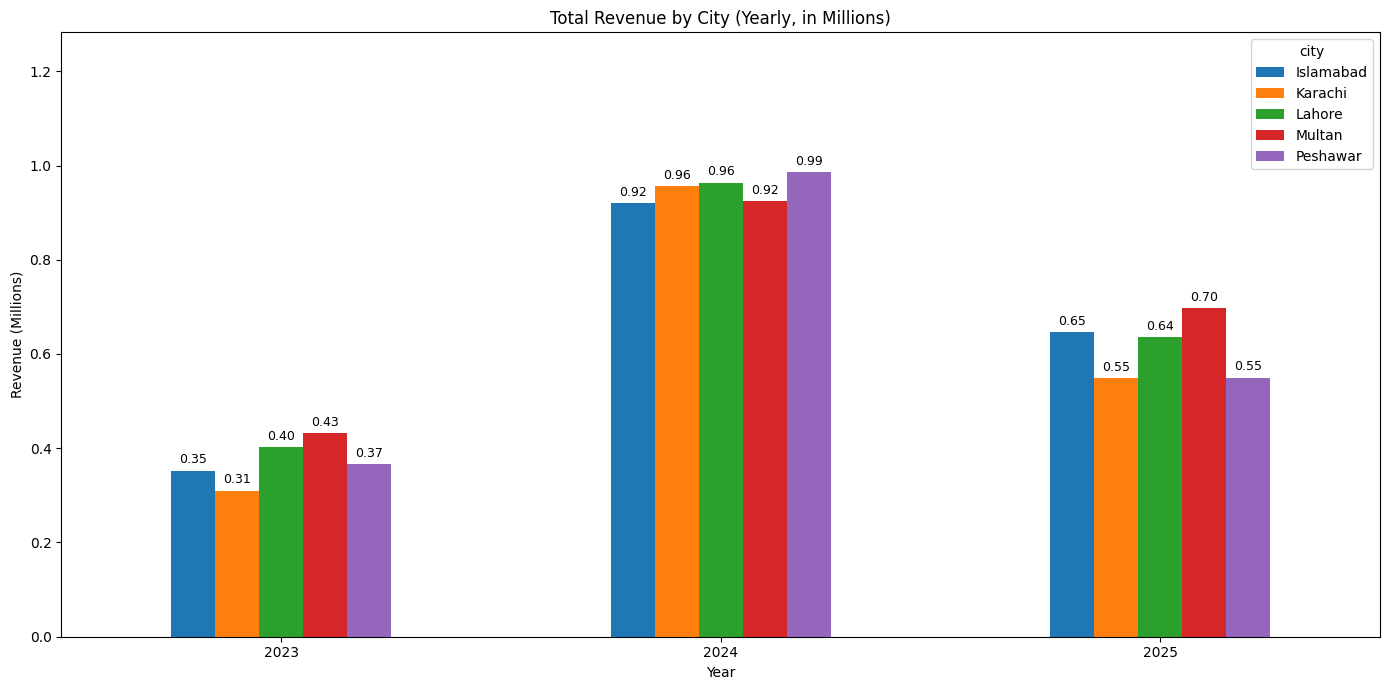

In [34]:


# Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# --- YEARLY ANALYSIS ---
df['year'] = df['order_date'].dt.year
city_yearly = df.groupby(['year','city'])['total_revenue'].sum().reset_index()

# Convert to millions
city_yearly['total_revenue'] = city_yearly['total_revenue'] / 1_000_000

# Pivot for plotting
pivot_yearly = city_yearly.pivot(index='year', columns='city', values='total_revenue')

# Plot yearly grouped bar chart
ax = pivot_yearly.plot(kind='bar', figsize=(14,7))
plt.title("Total Revenue by City (Yearly, in Millions)")
plt.ylabel("Revenue (Millions)")
plt.xlabel("Year")
plt.xticks(rotation=0)

# Add labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3, fontsize=9)

ax.set_ylim(0, pivot_yearly.max().max() * 1.3)
plt.tight_layout()
plt.savefig("CITY_YEARLY.png", dpi=300, bbox_inches='tight')
plt.show()

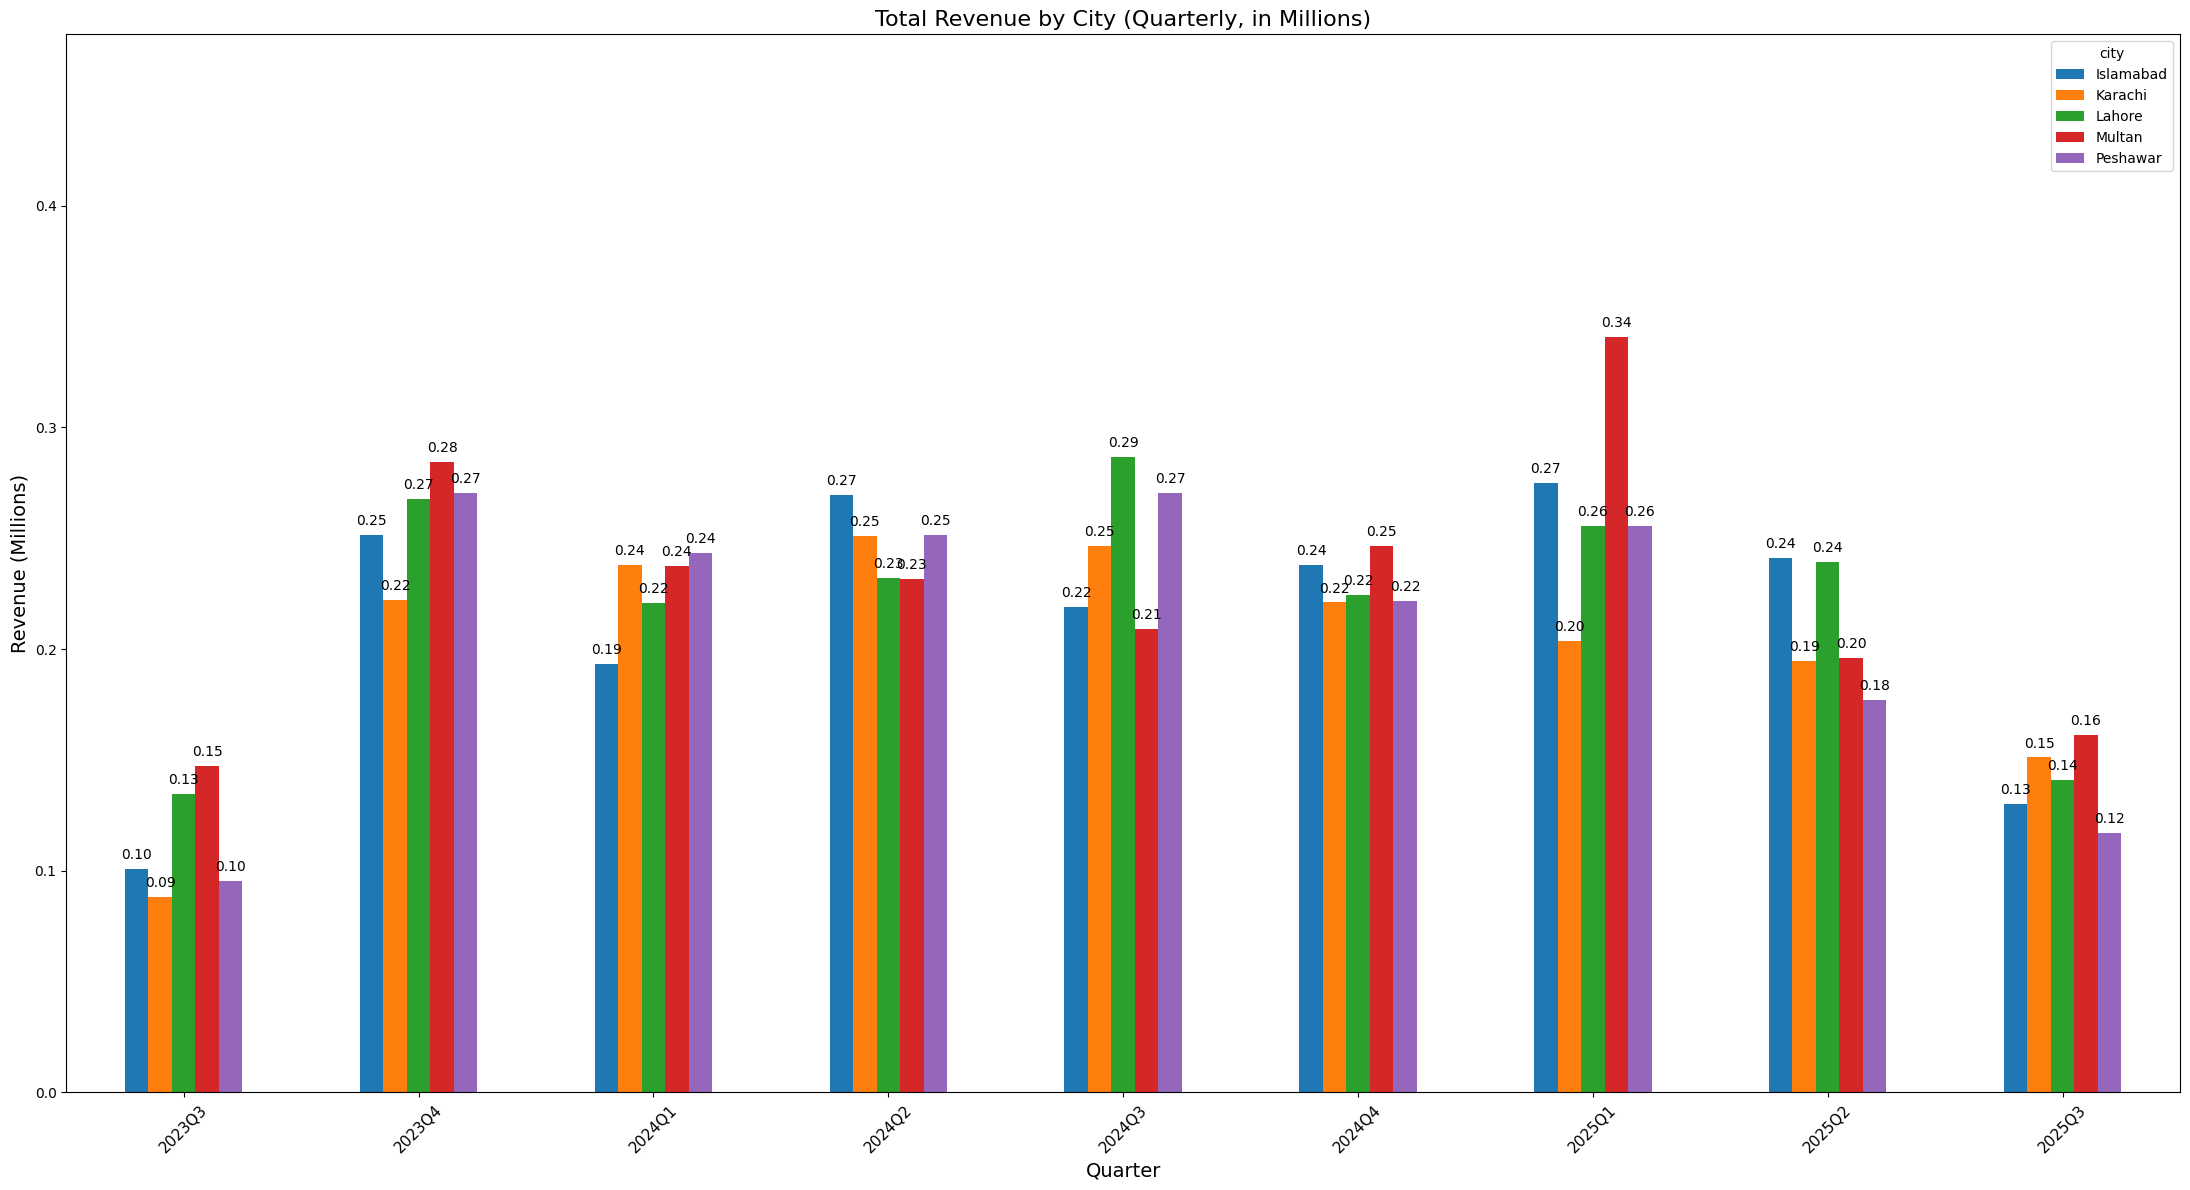

In [35]:
# --- QUARTERLY ANALYSIS ---
df['quarter'] = df['order_date'].dt.to_period('Q')
city_quarterly = df.groupby(['quarter','city'])['total_revenue'].sum().reset_index()

# Convert to millions
city_quarterly['total_revenue'] = city_quarterly['total_revenue'] / 1_000_000

# Pivot for plotting
pivot_quarterly = city_quarterly.pivot(index='quarter', columns='city', values='total_revenue')

# Plot quarterly grouped bar chart
ax = pivot_quarterly.plot(kind='bar', figsize=(22,12))  # bigger for clarity
plt.title("Total Revenue by City (Quarterly, in Millions)", fontsize=16)
plt.ylabel("Revenue (Millions)", fontsize=14)
plt.xlabel("Quarter", fontsize=14)
plt.xticks(rotation=45, fontsize=11)

# Add labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=5, fontsize=10)

ax.set_ylim(0, pivot_quarterly.max().max() * 1.4)
plt.tight_layout()
plt.savefig("CITY_QUA.png", dpi=300, bbox_inches='tight')
plt.show()

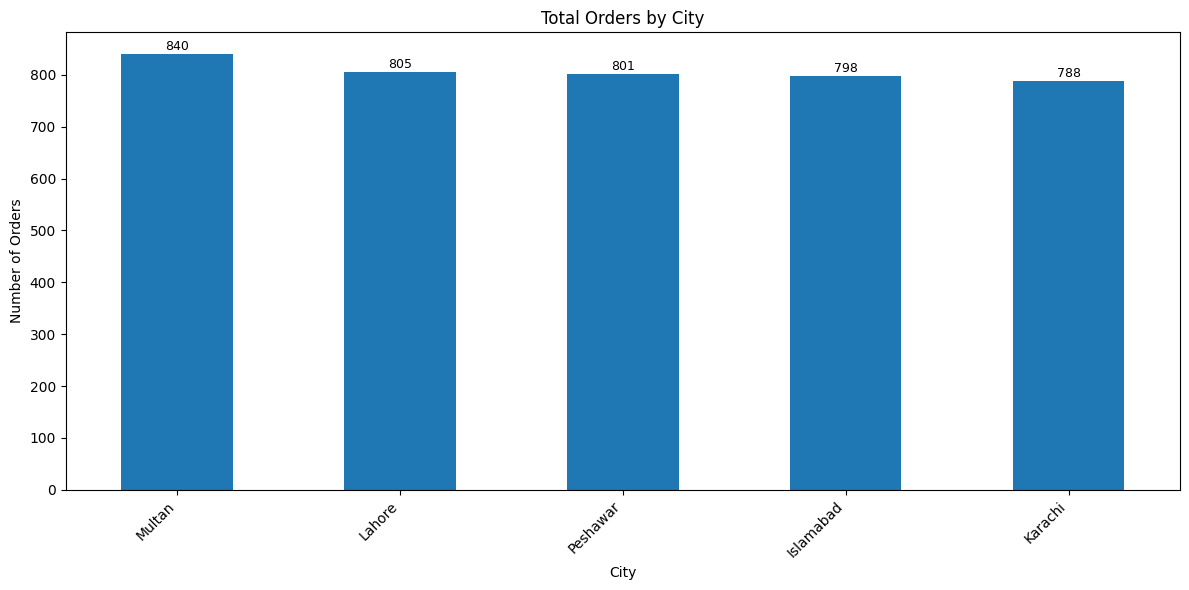

In [36]:
# --- TOTAL ORDERS PER CITY ---
city_orders = df.groupby('city')['order_id'].count().sort_values(ascending=False)

# Plot bar chart
ax = city_orders.plot(kind='bar', figsize=(12,6))

# Add labels above bars
for i, value in enumerate(city_orders):
    ax.text(i, value + (value * 0.01), f'{value}', ha='center', fontsize=9)

plt.title("Total Orders by City")
plt.ylabel("Number of Orders")
plt.xlabel("City")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [37]:
#by city done 

In [38]:
#How do customer demographics influence revenue generation
# gender
gender_analysis = df.groupby('gender')['total_revenue'].agg(['sum','mean'])
print(gender_analysis)

               sum         mean
gender                         
Female  3278646.40  2398.424579
Male    3338355.19  2443.891061
Other   3074769.24  2367.027898


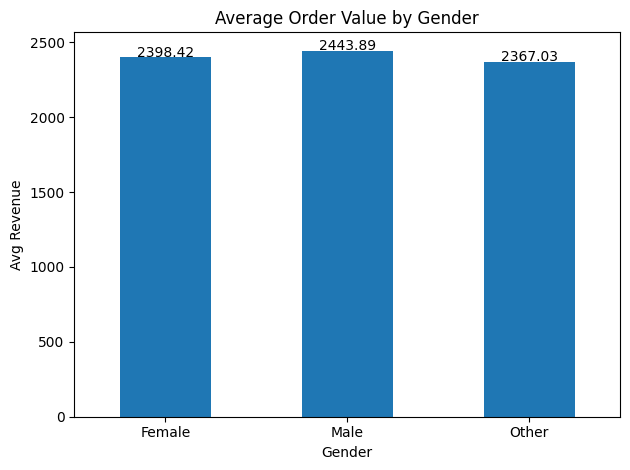

In [39]:
#How do customer demographics influence revenue generation
#by gender
# Plot Average Order Value by Gender
ax = gender_analysis['mean'].plot(kind='bar')

# Add value labels above bars
for i, value in enumerate(gender_analysis['mean']):
    ax.text(i, value + 5, f'{value:.2f}', ha='center')

plt.title("Average Order Value by Gender")
plt.ylabel("Avg Revenue")
plt.xlabel("Gender")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

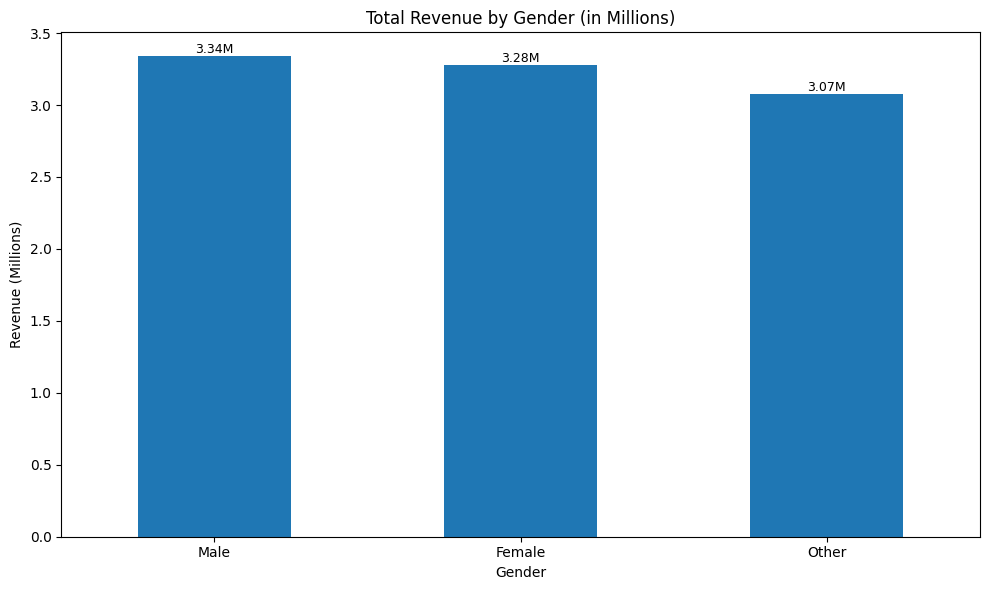

In [40]:
# --- TOTAL REVENUE BY GENDER ---
gender_revenue = df.groupby('gender')['total_revenue'].sum().sort_values(ascending=False) / 1_000_000

# Plot bar chart
ax = gender_revenue.plot(kind='bar', figsize=(10,6))

# Add value labels above each bar
for i, value in enumerate(gender_revenue):
    ax.text(i, value + 0.02, f'{value:.2f}M', ha='center', fontsize=9)

plt.title("Total Revenue by Gender (in Millions)")
plt.ylabel("Revenue (Millions)")
plt.xlabel("Gender")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

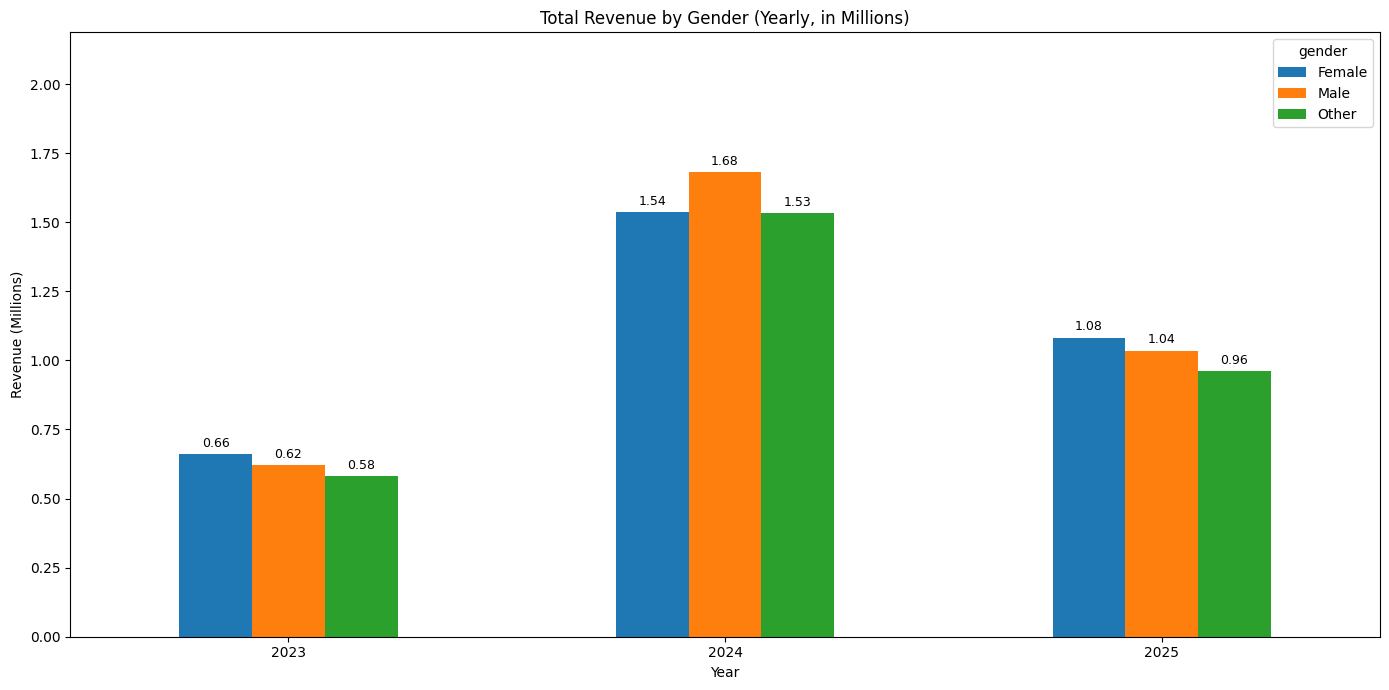

In [41]:
# Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# --- YEARLY ANALYSIS ---
df['year'] = df['order_date'].dt.year
gender_yearly = df.groupby(['year','gender'])['total_revenue'].sum().reset_index()

# Convert to millions
gender_yearly['total_revenue'] = gender_yearly['total_revenue'] / 1_000_000

# Pivot for plotting
pivot_yearly = gender_yearly.pivot(index='year', columns='gender', values='total_revenue')

# Plot yearly grouped bar chart
ax = pivot_yearly.plot(kind='bar', figsize=(14,7))
plt.title("Total Revenue by Gender (Yearly, in Millions)")
plt.ylabel("Revenue (Millions)")
plt.xlabel("Year")
plt.xticks(rotation=0)

# Add labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3, fontsize=9)

ax.set_ylim(0, pivot_yearly.max().max() * 1.3)
plt.tight_layout()
plt.show()

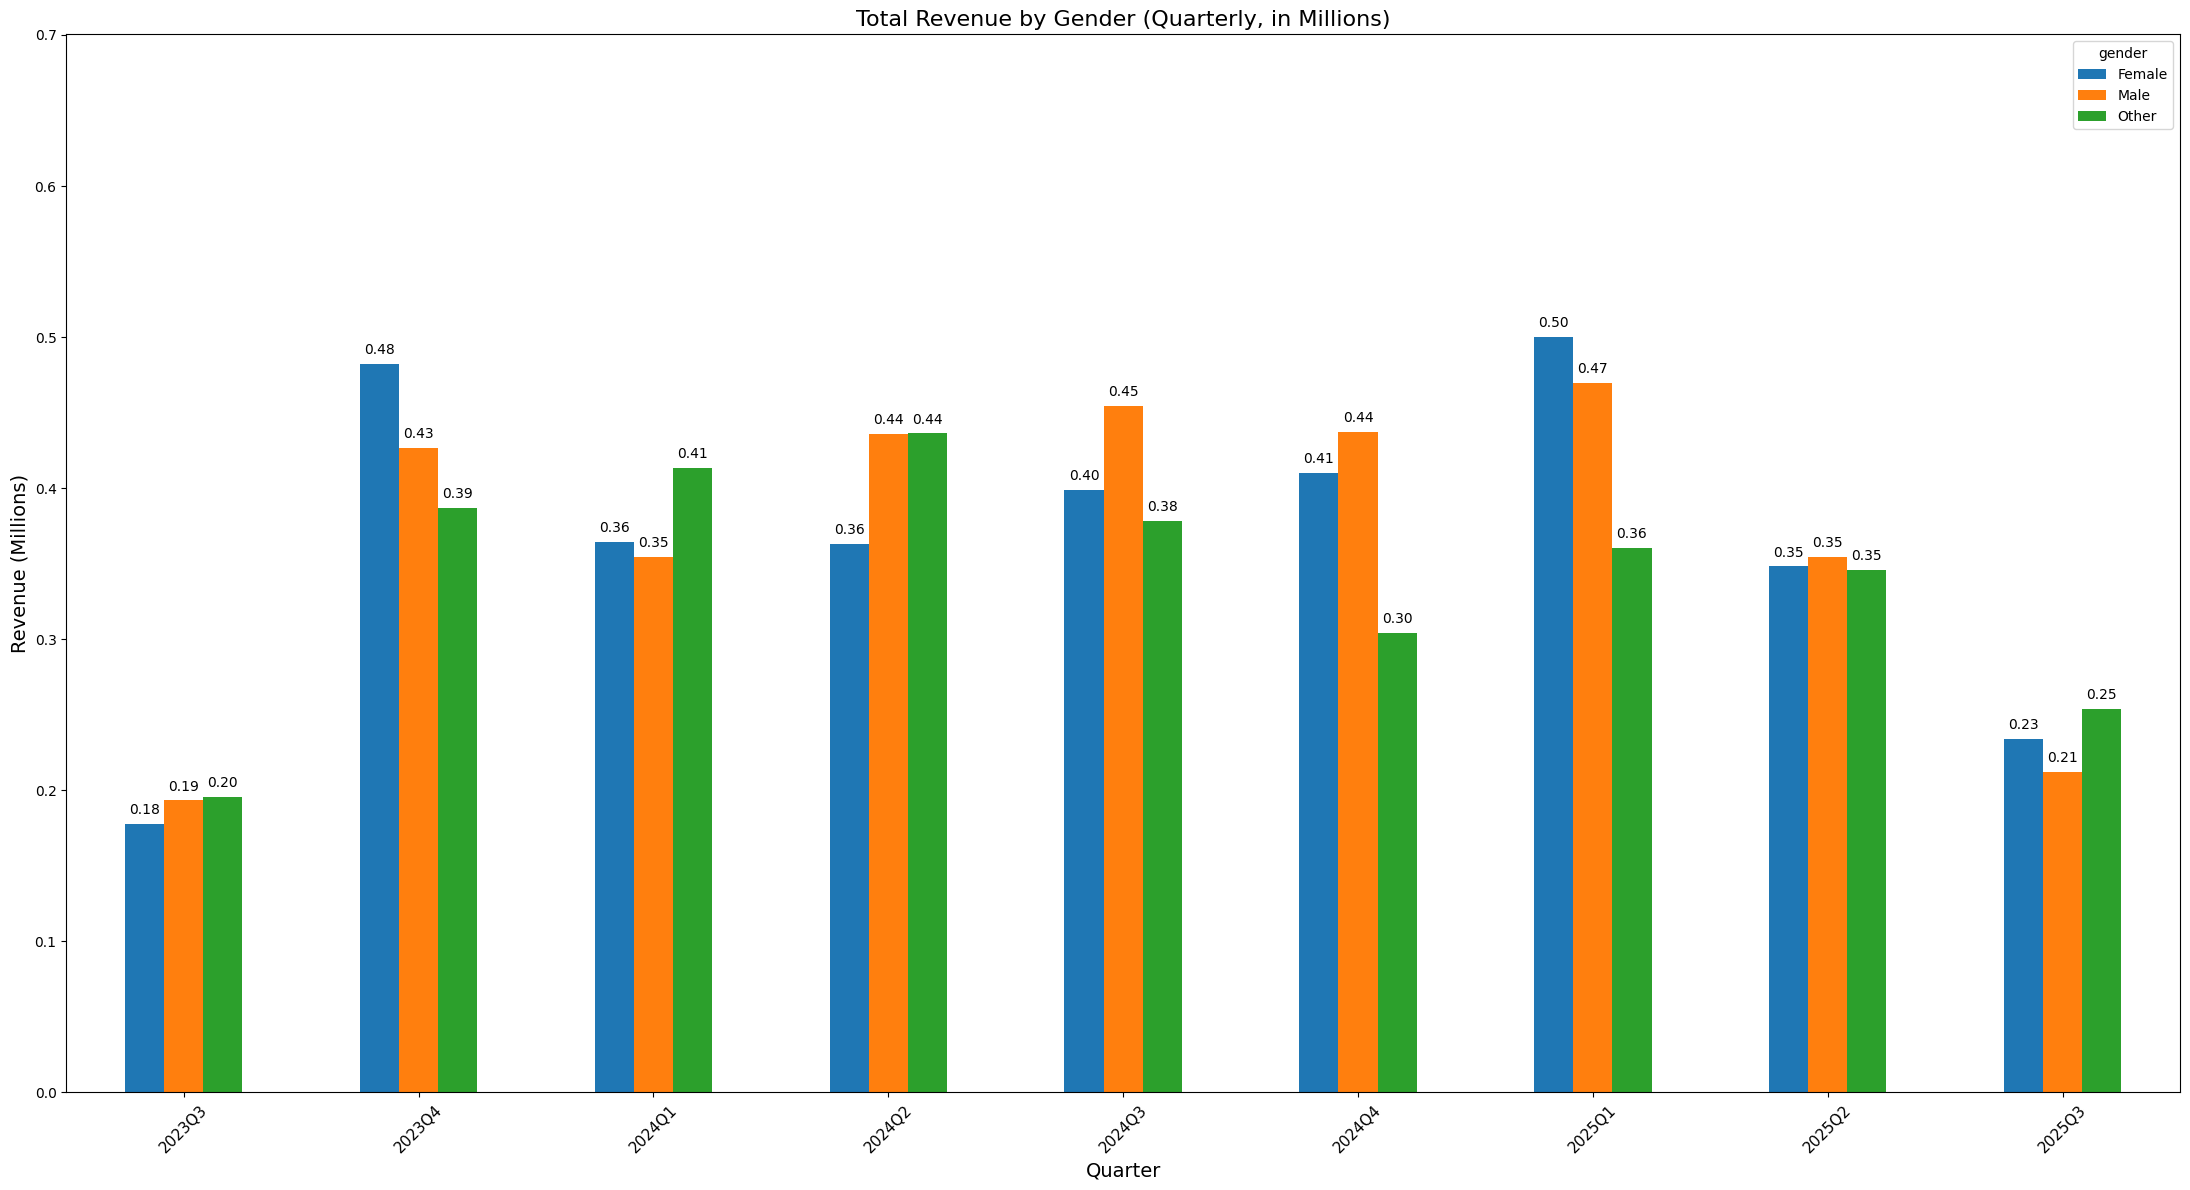

In [42]:
# --- QUARTERLY ANALYSIS ---
df['quarter'] = df['order_date'].dt.to_period('Q')
gender_quarterly = df.groupby(['quarter','gender'])['total_revenue'].sum().reset_index()

# Convert to millions
gender_quarterly['total_revenue'] = gender_quarterly['total_revenue'] / 1_000_000

# Pivot for plotting
pivot_quarterly = gender_quarterly.pivot(index='quarter', columns='gender', values='total_revenue')

# Plot quarterly grouped bar chart
ax = pivot_quarterly.plot(kind='bar', figsize=(22,12))  # larger for clarity
plt.title("Total Revenue by Gender (Quarterly, in Millions)", fontsize=16)
plt.ylabel("Revenue (Millions)", fontsize=14)
plt.xlabel("Quarter", fontsize=14)
plt.xticks(rotation=45, fontsize=11)

# Add labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=5, fontsize=10)

ax.set_ylim(0, pivot_quarterly.max().max() * 1.4)
plt.tight_layout()
plt.show()

gender
Female    1367
Male      1366
Other     1299
Name: count, dtype: int64


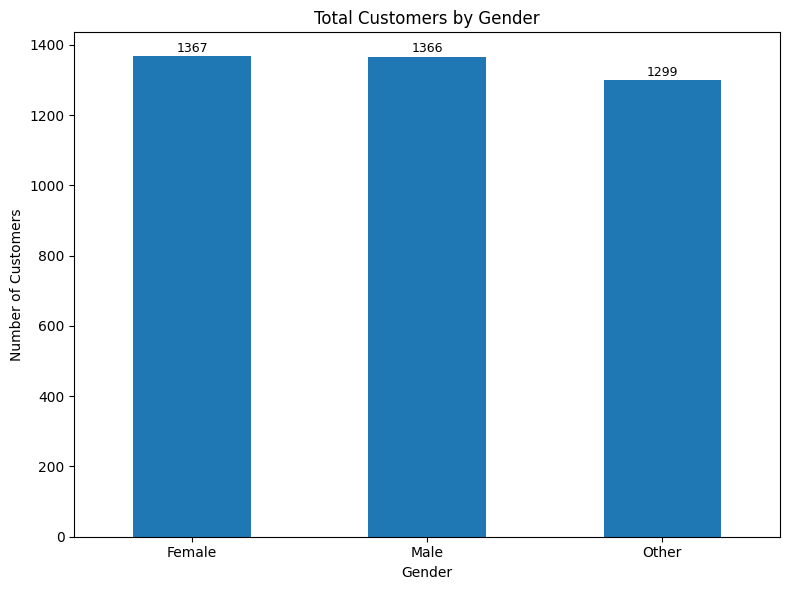

In [43]:
# --- TOTAL CUSTOMERS BY GENDER ---
gender_counts = df['gender'].value_counts()

print(gender_counts)

# Plot bar chart
ax = gender_counts.plot(kind='bar', figsize=(8,6))

# Add labels above bars
for i, value in enumerate(gender_counts):
    ax.text(i, value + (value * 0.01), f'{value}', ha='center', fontsize=9)

plt.title("Total Customers by Gender")
plt.ylabel("Number of Customers")
plt.xlabel("Gender")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [44]:
# Assuming your DataFrame is called df
df.to_csv("dataset_changes.csv", index=False)
